Synthesizing 256x256 High-Res object from 49 Low-Res 64x64 captures.
Running reconstruction for 30 iterations...


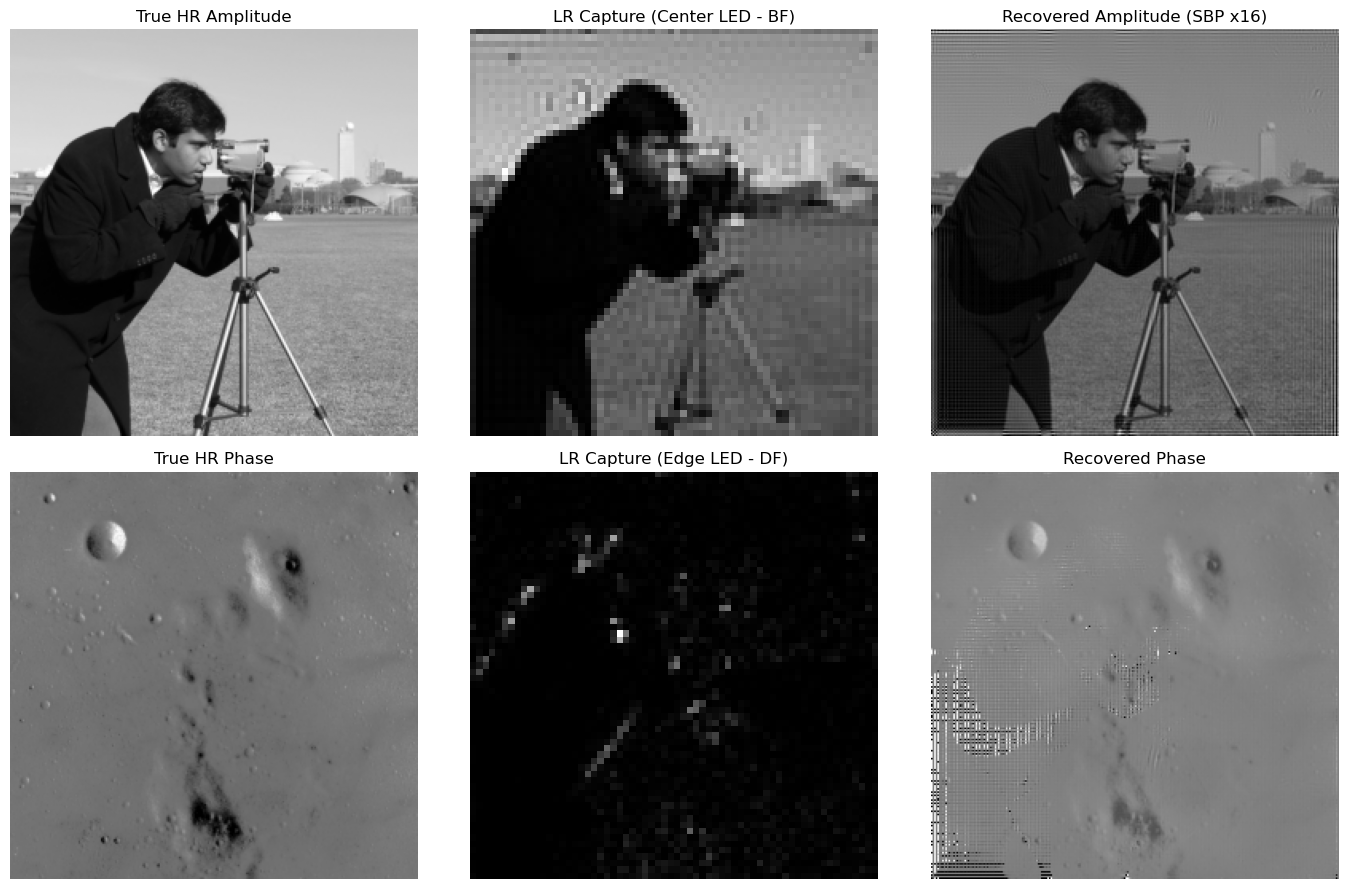

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def run_fpm_simulation():
    # ==========================================
    # 1. SYSTEM PARAMETERS & OPTICAL SETUP
    # ==========================================
    # Illumination & Setup
    wavelength = 0.532e-6      # Green LED wavelength (m)
    n_leds_1d = 7              # 7x7 LED array
    led_pitch = 4e-3           # 4mm spacing between LEDs
    z_led = 60e-3              # 60mm distance from LED to sample
    
    # Objective Lens & Camera
    NA = 0.08                   # Objective Numerical Aperture
    mag = 2.0                  # Magnification
    dpix_c = 6.5e-6            # Typical sCMOS camera pixel size (m)
    dpix_o = dpix_c / mag      # Effective pixel size at the object plane (3.25 um)
    
    # Grid Sizes (Powers of 2 for efficient FFT)
    N_LR = 64                  # Low-Res image dimensions (64x64)
    ds = 4                     # Upsampling factor for High-Res reconstruction
    N_HR = N_LR * ds           # High-Res object dimensions (256x256)
    dpix_HR = dpix_o / ds      # High-Res pixel size (0.8125 um)

    print(f"Synthesizing {N_HR}x{N_HR} High-Res object from {n_leds_1d**2} Low-Res {N_LR}x{N_LR} captures.")

    # ==========================================
    # 2. GENERATE GROUND TRUTH OBJECT
    # ==========================================
    # Amplitude: Cameraman, Phase: Moon
    amp = transform.resize(data.camera(), (N_HR, N_HR), anti_aliasing=True)
    amp = amp / amp.max() 
    
    phase = transform.resize(data.moon(), (N_HR, N_HR), anti_aliasing=True)
    phase = (phase / phase.max()) * np.pi - (np.pi/2) # Scale phase between -pi/2 and pi/2
    
    obj_true = amp * np.exp(1j * phase)
    
    # High-Res frequency space coordinates
    df_HR = 1.0 / (N_HR * dpix_HR)
    
    # ==========================================
    # 3. CONSTRUCT THE PUPIL FUNCTION (CTF)
    # ==========================================
    # The pupil acts as a low-pass filter in the Fourier domain
    fx_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=dpix_o))
    fy_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=dpix_o))
    FX_LR, FY_LR = np.meshgrid(fx_LR, fy_LR)
    
    cutoff_freq = NA / wavelength
    pupil = (FX_LR**2 + FY_LR**2 <= cutoff_freq**2).astype(float)
    
    # ==========================================
    # 4. FORWARD MODEL (SIMULATING LR CAPTURES)
    # ==========================================
    # Calculate LED positions and corresponding frequency shifts
    led_idx = np.arange(-(n_leds_1d//2), n_leds_1d//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_pitch, led_idx * led_pitch)
    
    # Illumination angles and k-vector shifts
    sin_theta_x = x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
    sin_theta_y = y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
    
    kx_led = -sin_theta_x / wavelength
    ky_led = -sin_theta_y / wavelength
    
    # Generate HR Object Spectrum
    O_HR = np.fft.fftshift(np.fft.fft2(obj_true))
    
    # Store captured Low-Res intensity images
    I_measure = np.zeros((n_leds_1d, n_leds_1d, N_LR, N_LR))
    
    for i in range(n_leds_1d):
        for j in range(n_leds_1d):
            # Calculate shift in matrix indices
            c_x = int(N_HR/2 + kx_led[i,j] / df_HR)
            c_y = int(N_HR/2 + ky_led[i,j] / df_HR)
            
            # Extract shifted spectrum patch
            patch = O_HR[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2]
            
            # Apply objective pupil
            patch_filtered = patch * pupil
            
            # Inverse FFT to sensor plane
            lr_field = np.fft.ifft2(np.fft.ifftshift(patch_filtered))
            
            # Camera captures intensity (absolute square)
            I_measure[i,j] = np.abs(lr_field)**2

    # ==========================================
    # 5. INVERSE MODEL (FPM RECONSTRUCTION)
    # ==========================================
    # Gerchberg-Saxton / Alternating Projections algorithm
    iterations = 30
    alpha = 1.0 # Step size / relaxation parameter
    
    # Initialize guess (upsampled central image)
    center_idx = n_leds_1d // 2
    init_amp = transform.resize(np.sqrt(I_measure[center_idx, center_idx]), (N_HR, N_HR))
    O_rec = np.fft.fftshift(np.fft.fft2(init_amp)) 
    
    print(f"Running reconstruction for {iterations} iterations...")
    
    for it in range(iterations):
        # Optional: Randomize or spiral LED update order for better convergence
        for i in range(n_leds_1d):
            for j in range(n_leds_1d):
                c_x = int(N_HR/2 + kx_led[i,j] / df_HR)
                c_y = int(N_HR/2 + ky_led[i,j] / df_HR)
                
                # 1. Extract current guess spectrum patch
                patch_rec = O_rec[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2]
                
                # 2. Apply pupil
                patch_filtered_rec = patch_rec * pupil
                
                # 3. Transform to spatial domain
                lr_field_rec = np.fft.ifft2(np.fft.ifftshift(patch_filtered_rec))
                
                # 4. Amplitude Constraint: Replace calculated amplitude with measured amplitude
                lr_field_updated = np.sqrt(I_measure[i,j]) * np.exp(1j * np.angle(lr_field_rec))
                
                # 5. Transform back to frequency domain
                patch_updated = np.fft.fftshift(np.fft.fft2(lr_field_updated)) * pupil
                
                # 6. Update High-Res spectrum (with support mask)
                O_rec[c_y - N_LR//2 : c_y + N_LR//2, c_x - N_LR//2 : c_x + N_LR//2] += \
                    alpha * np.abs(pupil) * (patch_updated - patch_filtered_rec)

    # Recover final spatial HR object
    obj_rec = np.fft.ifft2(np.fft.ifftshift(O_rec))

    # ==========================================
    # 6. VISUALIZATION
    # ==========================================
    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    
    axs[0,0].imshow(np.abs(obj_true), cmap='gray')
    axs[0,0].set_title('True HR Amplitude')
    axs[0,0].axis('off')
    
    axs[1,0].imshow(np.angle(obj_true), cmap='gray')
    axs[1,0].set_title('True HR Phase')
    axs[1,0].axis('off')
    
    # Show center LED (Brightfield) vs Edge LED (Darkfield)
    axs[0,1].imshow(I_measure[center_idx, center_idx], cmap='gray')
    axs[0,1].set_title('LR Capture (Center LED - BF)')
    axs[0,1].axis('off')
    
    axs[1,1].imshow(I_measure[0, 0], cmap='gray')
    axs[1,1].set_title('LR Capture (Edge LED - DF)')
    axs[1,1].axis('off')
    
    axs[0,2].imshow(np.abs(obj_rec), cmap='gray')
    axs[0,2].set_title(f'Recovered Amplitude (SBP x{ds**2})')
    axs[0,2].axis('off')
    
    axs[1,2].imshow(np.angle(obj_rec), cmap='gray')
    axs[1,2].set_title('Recovered Phase')
    axs[1,2].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_fpm_simulation()